In [5]:
!pip install scipy



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

## Dataset


In [7]:
# creating database connection
conn = sqlite3.connect('inventory.db')

# fetching vendor summary data
df = pd.read_sql_query("select * from vendor_sales_summary",conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,710245.0,25509597.55,3364096.55,1304996.00,68601.68,21698345.95,85.059539,4.895540,6.693234
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,801235.0,24095367.45,2807561.85,1472193.30,144929.24,20291326.23,84.212562,4.884448,6.334150
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,935700.0,22690603.00,2305700.75,1719270.35,123780.22,19272299.32,84.935157,4.992876,6.637972
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,1002060.0,22379864.40,2100250.05,1841214.00,257032.07,19118666.46,85.427982,4.968515,6.862467
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,679190.0,21115538.10,2728891.40,1247939.15,257032.07,18092332.09,85.682553,4.917782,6.984485


In [8]:
df.to_csv('vendor_sales_summary.csv',index  = False)

## Exploratory Data Analysis

Previously, we examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.

In this phase of EDA, we analyze the resultant table to gain insights into the distribution of each column. This helps in understanding data patterns, detecting anomalies, and ensuring data quality before proceeding with further analysis and modeling.


In [9]:
# Summary statistics for numerical columns
summary_stats = df.describe().T  
display(summary_stats)

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,1.538741e+04,54764.256954,0.00,165.000000,1305.000000,9646.250000,1.674695e+06
TotalSalesDollars,10692.0,2.111954e+05,838276.329919,0.00,3646.100000,26490.225000,141984.575000,2.550960e+07
TotalSalesPrice,10692.0,9.396892e+04,224763.866928,0.00,1448.550000,14289.000000,80297.812500,3.364097e+06


In [10]:
# Mode for each numerical column
mode_values = df.mode().iloc[0]
print("\nMode Values:\n\n", mode_values)


Mode Values:

 VendorNumber                            4425.0
VendorName               MARTIGNETTI COMPANIES
Brand                                      809
Description                   Southern Comfort
PurchasePrice                             6.53
ActualPrice                               9.99
Volume                                   750.0
TotalPurchaseQuantity                     12.0
TotalPurchaseDollars                     95.28
TotalSalesQuantity                        60.0
TotalSalesDollars                          0.0
TotalSalesPrice                            0.0
TotalExciseTax                             0.0
FreightCost                          144929.24
GrossProfit                             -106.8
ProfitMargin                              -inf
StockTurnover                              5.0
SalesToPurchaseRatio                       0.0
Name: 0, dtype: object


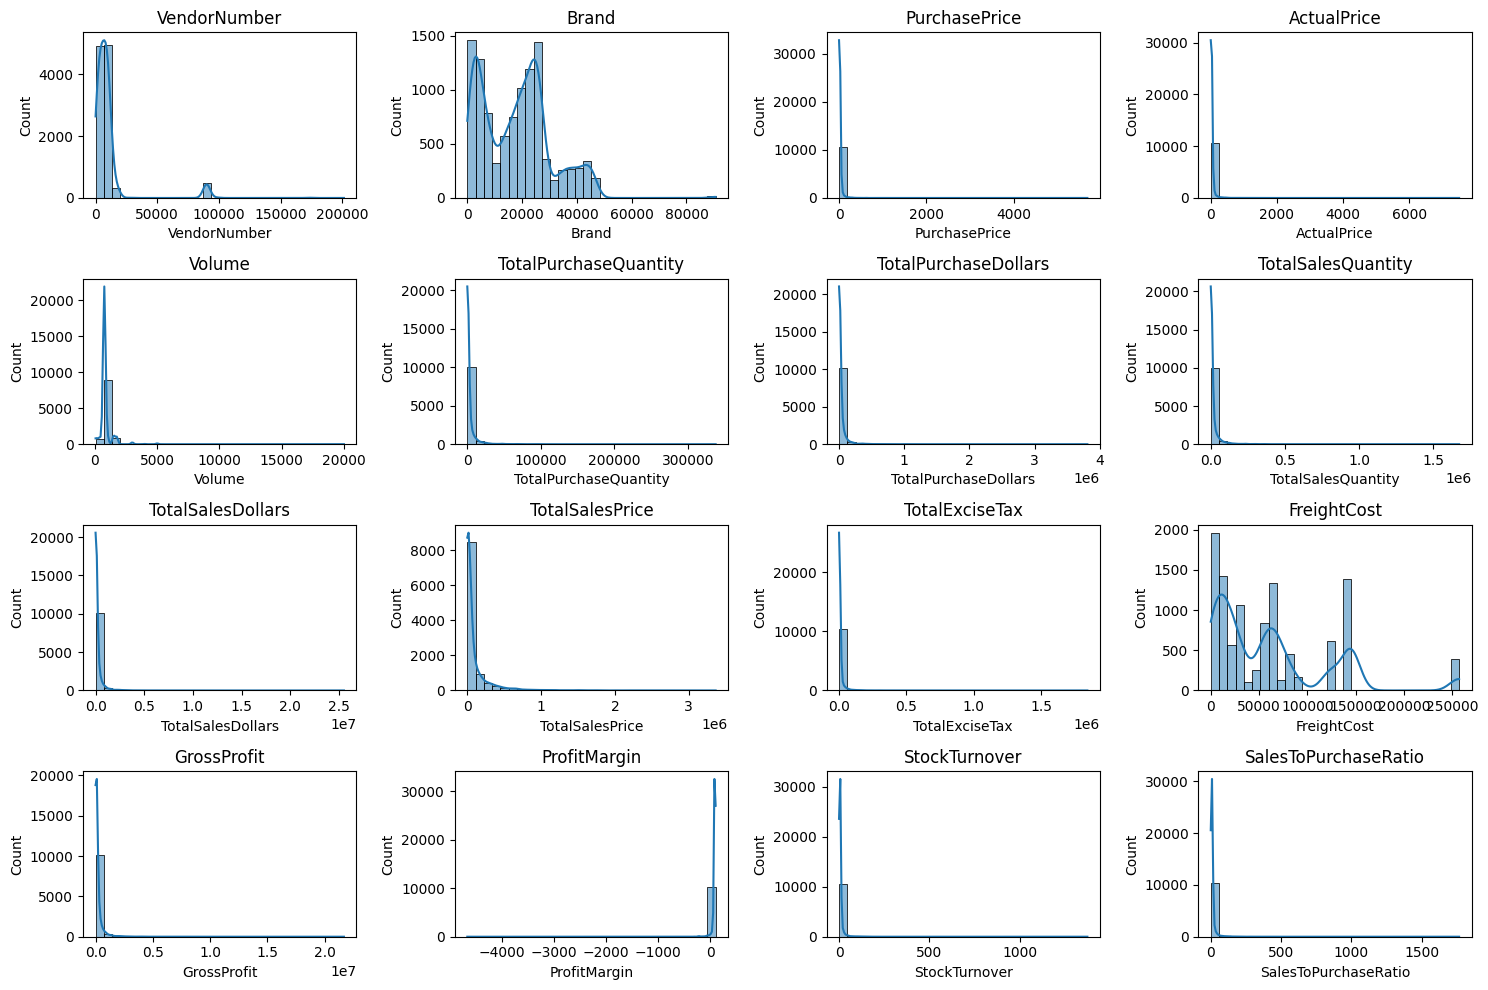

In [11]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)  # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

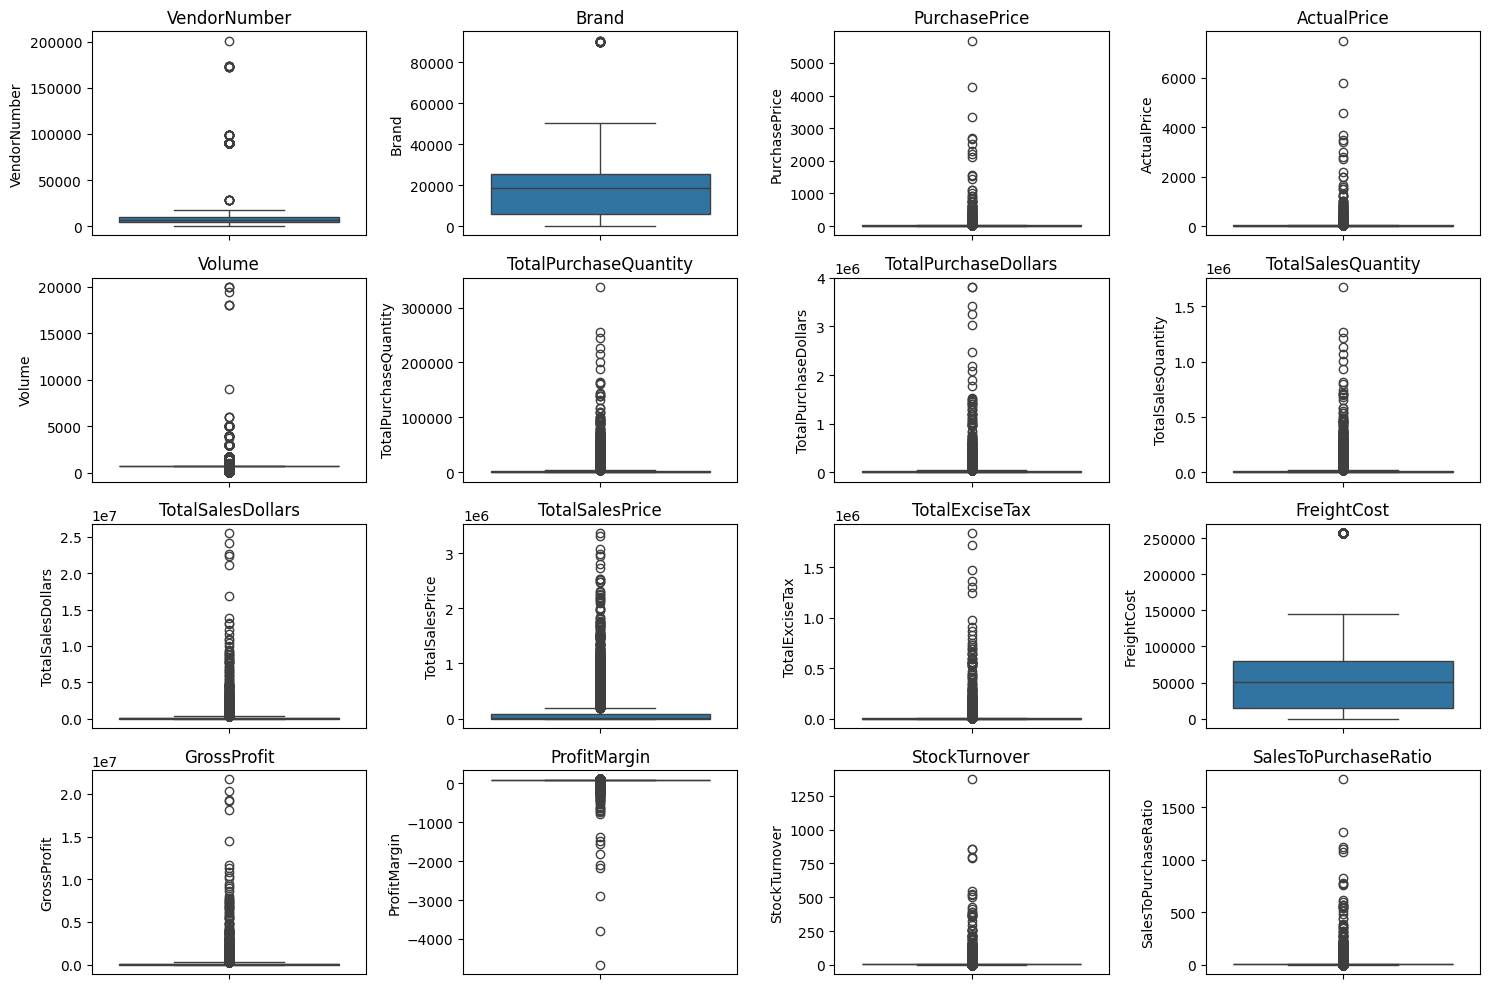

In [12]:
# Outlier Detection with Boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

### Summary Statistics Insights

#### 🔴 Negative & Zero Values
- **Gross Profit:** The minimum value is **-52,002.78**, which means some products are being sold at a loss. This can happen if selling prices are lower than purchase costs or due to heavy discounts.
- **Profit Margin:** The minimum value shows **-∞**, which suggests there are cases where sales revenue is zero or extremely low compared to costs.
- **Total Sales Quantity & Sales Dollars:** Some values are **0**, meaning certain products were purchased but never sold. These products may be slow-moving or outdated stock.

#### 📊 Outliers and Large Variations
- **Purchase Price & Actual Price:** Maximum values (**5,681.81** and **7,499.99**) are much higher than the average prices (**24.39** and **35.64**). This indicates the presence of premium or high-value products.
- **Freight Cost:** Values vary widely from **0.09 to 257,032.07**, which may indicate differences in shipping methods, bulk orders, or logistics inefficiencies.
- **Stock Turnover:** Ranges from **0 to 274.5**, showing that some products sell very quickly while others remain unsold for long periods. A value greater than **1** suggests that sales are fulfilled using older stock as well.


In [14]:
# let's filter the data by removing inconsistencies
df = pd.read_sql_query("""SELECT * 
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0""",conn)

In [15]:
df.shape

(10238, 18)

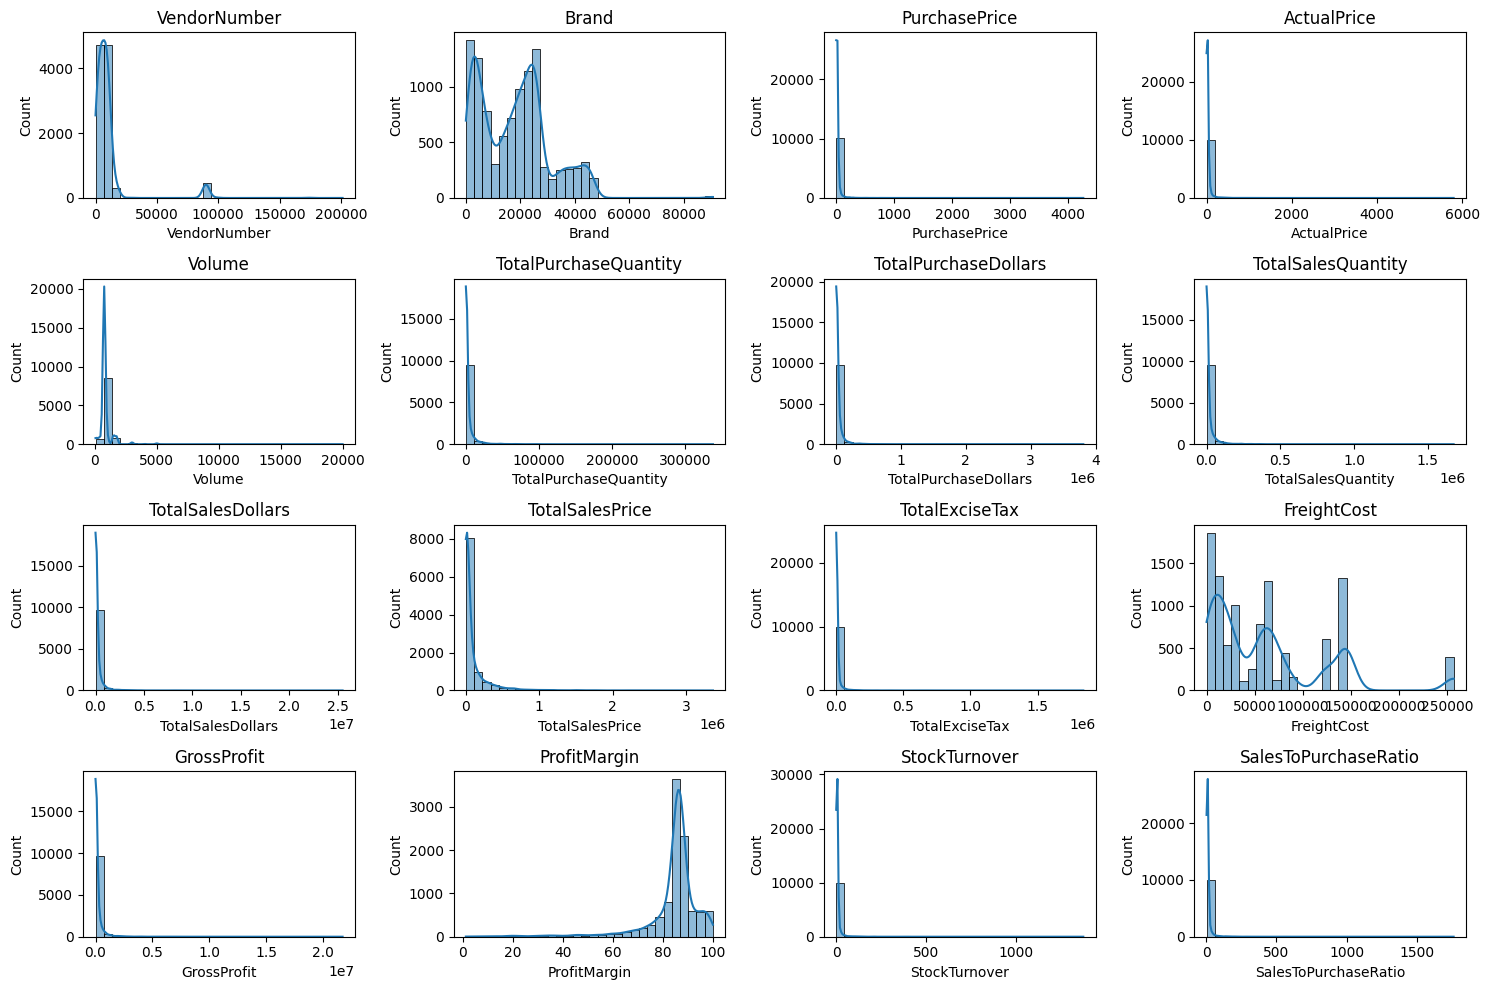

In [16]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)  # Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

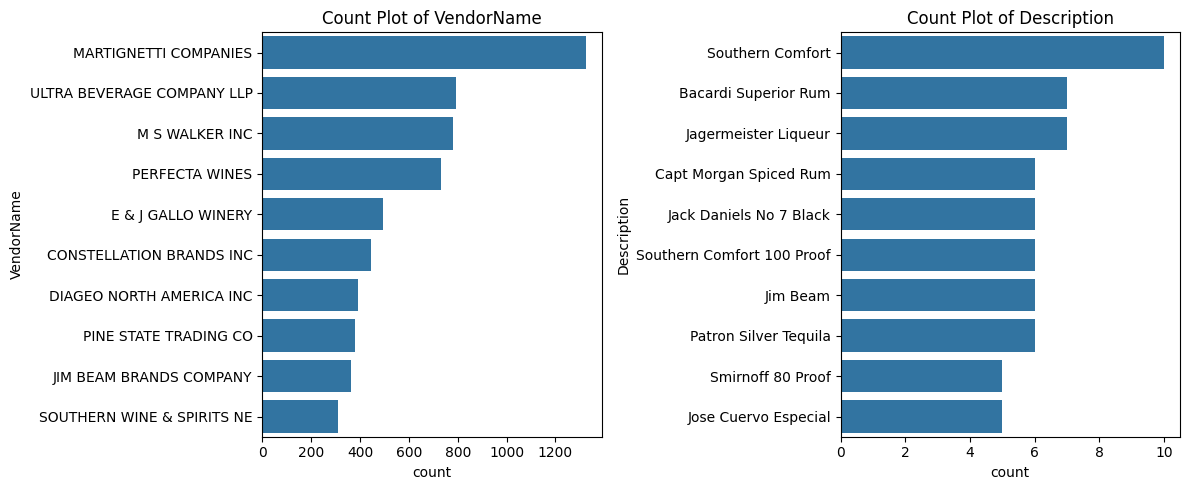

In [17]:
# Count Plots for Categorical Columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])  # Top 10 categories
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

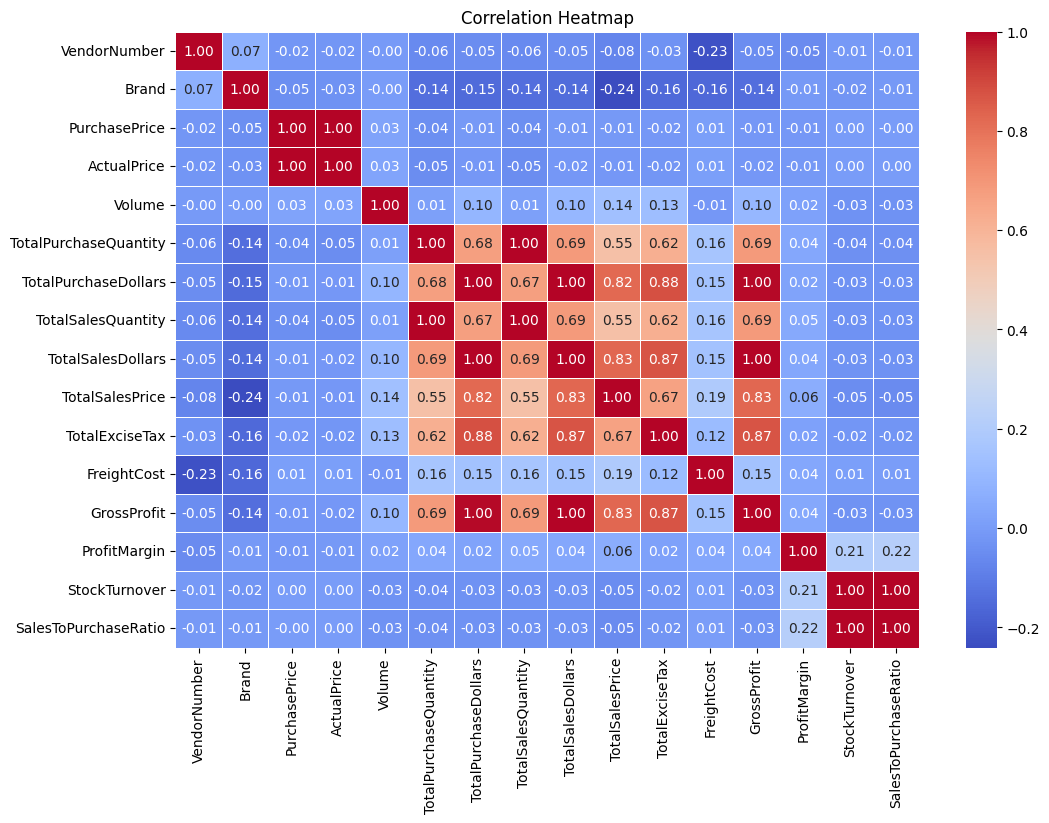

In [18]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## Correlation Insights

- **Purchase Price vs Sales & Profit:**  
  Purchase price shows a very weak relationship with total sales and gross profit. This means that small changes in purchase price do not strongly affect sales revenue or overall profit.

- **Purchase Quantity vs Sales Quantity:**  
  There is a very strong relationship between total purchase quantity and total sales quantity. This shows that the inventory is being managed efficiently, as most purchased products are getting sold.

- **Profit Margin vs Sales Price:**  
  There is a slight negative relationship between profit margin and sales price. This suggests that when sales prices increase, profit margins may decrease, possibly because of competitive market pricing.

- **Stock Turnover vs Profitability:**  
  Stock turnover has a weak negative relationship with both gross profit and profit margin. This means that selling products faster does not always guarantee higher profit.

---

## Data Analysis

- Brands that have **low sales but high profit margins** may benefit from promotional activities or pricing adjustments.
- Improving marketing or adjusting pricing strategies for such brands can help increase their sales performance while maintaining profitability.


In [19]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars': 'sum',  # Sales performance metric
    'ProfitMargin': 'mean'       # Average profit margin
}).reset_index()

brand_performance.sort_values('ProfitMargin')

,Description,TotalSalesDollars,ProfitMargin
6152,Nicolas Perrin Cote Rotie 11,1199.80,1.308551
5732,Menage a Trois Prosecco,599.60,1.334223
5327,Loch Lomond Original Scotch,5438.30,1.825203
7844,Solar De Randez Rioja,209.85,2.215868
8943,W Selyum Pnt Nr Foss Vyd RRV,2149.75,2.704966
...,...,...,...
5445,M Chiarlo Gavi Wh,6044.50,99.878733
780,Beniotome Sesame Shochu,23842.05,99.906845
7723,Skinnygirl Tangerine Vodka,11842.10,99.908969
2833,DiSaronno Amaretto,23905.80,99.910649


In [20]:
# threshold for "low sales" (bottom 15%) and "high margin" (top 15%)
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

# Filter brands with low sales but high profit margins
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]
print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
7422,Santa Rita Organic Svgn Bl,49.95,93.293293
2786,Debauchery Pnt Nr,57.90,93.195164
2443,Concannon Glen Ellen Wh Zin,79.75,96.689655
2574,Crown Royal Apple,139.30,97.961235
7463,Sauza Sprklg Wild Berry Marg,139.80,96.430615
...,...,...,...
1268,C Monaci Kreos Rosato,1978.90,93.240689
3700,Galliano Tiki Gift Pack,1993.95,97.113268
3039,Dr McGillicudy's Buttersctch,1994.85,97.227862
546,Bacardi Oakheart Spiced Trav,1998.00,99.626627


In [21]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars']<10000] # for better visualization

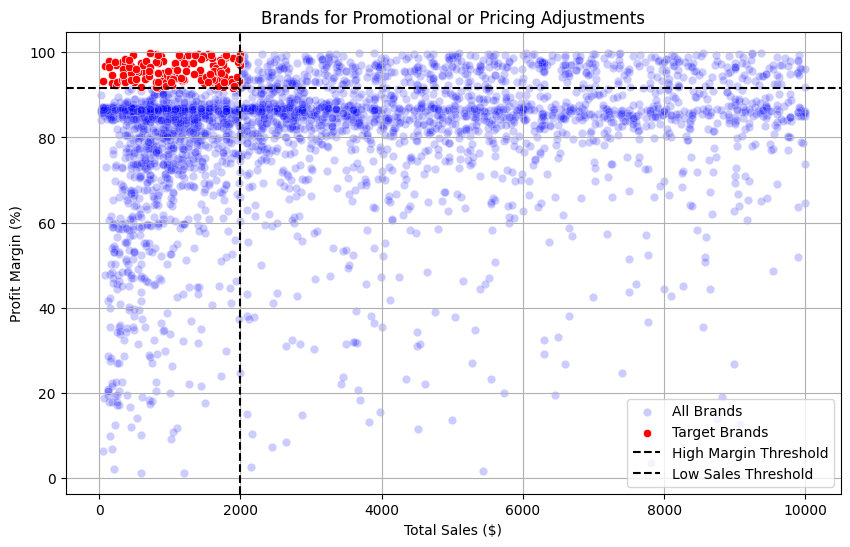

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Brands", alpha = 0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color="red", label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

## Which vendors and brands demonstrate the highest sales performance?

In [23]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [24]:
# Top Vendors & Brands by Sales Performance
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      3.436564e+08
MARTIGNETTI COMPANIES         2.047270e+08
PERNOD RICARD USA             1.613977e+08
JIM BEAM BRANDS COMPANY       1.594702e+08
BACARDI USA INC               1.250268e+08
CONSTELLATION BRANDS INC      1.223349e+08
E & J GALLO WINERY            9.276386e+07
BROWN-FORMAN CORP             9.237295e+07
ULTRA BEVERAGE COMPANY LLP    8.887835e+07
M S WALKER INC                7.709505e+07
Name: TotalSalesDollars, dtype: float64

In [25]:
top_vendors.apply(lambda x:format_dollars(x))

VendorName
DIAGEO NORTH AMERICA INC      343.66M
MARTIGNETTI COMPANIES         204.73M
PERNOD RICARD USA             161.40M
JIM BEAM BRANDS COMPANY       159.47M
BACARDI USA INC               125.03M
CONSTELLATION BRANDS INC      122.33M
E & J GALLO WINERY             92.76M
BROWN-FORMAN CORP              92.37M
ULTRA BEVERAGE COMPANY LLP     88.88M
M S WALKER INC                 77.10M
Name: TotalSalesDollars, dtype: object

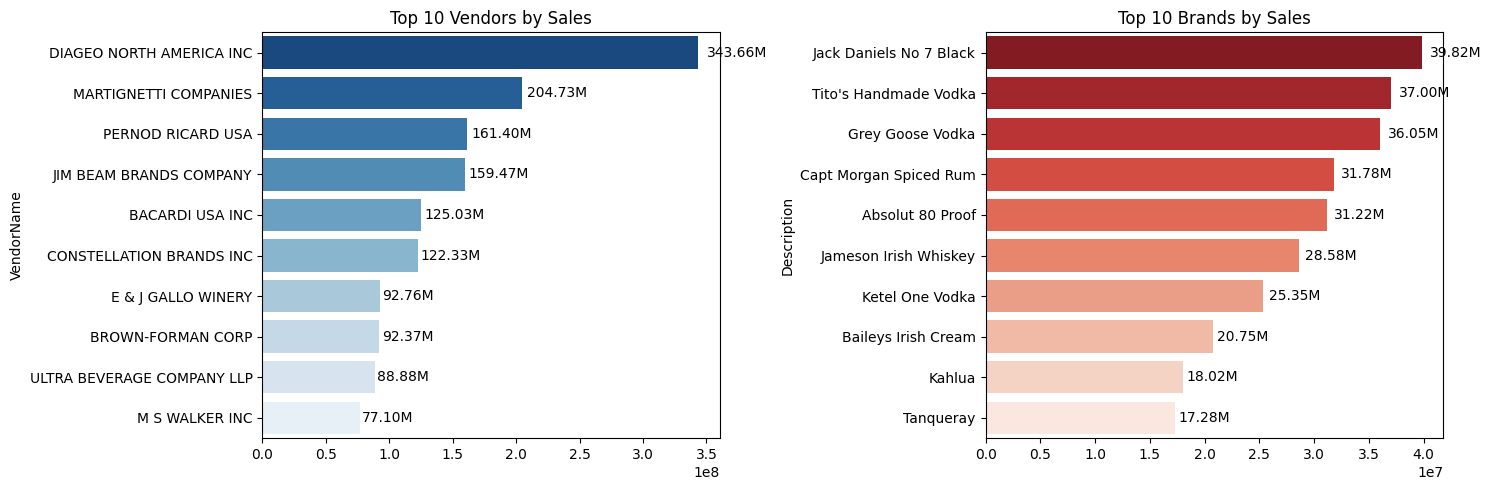

In [26]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02), 
             bar.get_y() + bar.get_height() / 2, 
             format_dollars(bar.get_width()), 
             ha='left', va='center', fontsize=10, color='black')

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02), 
             bar.get_y() + bar.get_height() / 2, 
             format_dollars(bar.get_width()), 
             ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()


## Which vendors contribute the most to total purchase dollars?

In [27]:
# Rank Vendors by Total Purchase Dollars
vendor_performance = df.groupby("VendorName").agg({
    "TotalPurchaseDollars": "sum",
    "GrossProfit": "sum",
    "TotalSalesDollars":"sum"
}).reset_index()

# Calculate Contribution % to Overall Procurement
vendor_performance["Purchase_Contribution%"] = (vendor_performance["TotalPurchaseDollars"] / vendor_performance["TotalPurchaseDollars"].sum()) * 100

# Rank Vendors by Total Purchase Dollars & Profitability
vendor_performance = round(vendor_performance.sort_values(by="TotalPurchaseDollars", ascending=False),2)

# Display Top 10 Vendors
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,Purchase_Contribution%
27,DIAGEO NORTH AMERICA INC,50.91M,292.74M,343.66M,15.88
61,MARTIGNETTI COMPANIES,27.66M,177.07M,204.73M,8.63
49,JIM BEAM BRANDS COMPANY,24.16M,135.31M,159.47M,7.53
72,PERNOD RICARD USA,24.12M,137.27M,161.40M,7.52
7,BACARDI USA INC,17.62M,107.40M,125.03M,5.50
22,CONSTELLATION BRANDS INC,15.57M,106.77M,122.33M,4.86
13,BROWN-FORMAN CORP,13.51M,78.86M,92.37M,4.21
111,ULTRA BEVERAGE COMPANY LLP,12.90M,75.98M,88.88M,4.02
32,E & J GALLO WINERY,12.28M,80.48M,92.76M,3.83
57,M S WALKER INC,10.70M,66.39M,77.10M,3.34


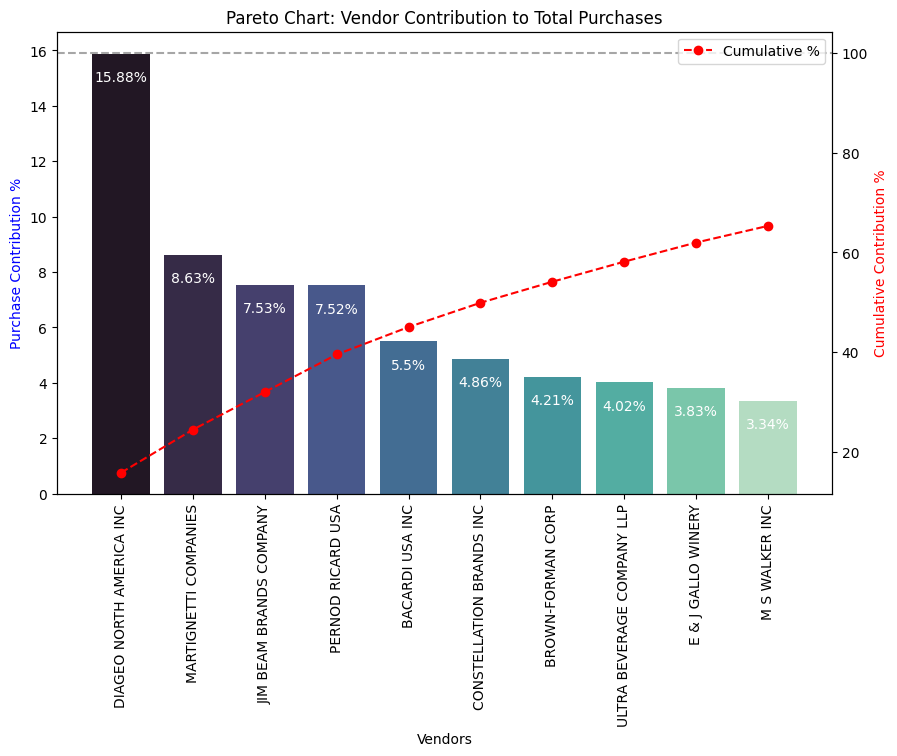

In [28]:
top_vendors['Cumulative_Contribution%'] = top_vendors['Purchase_Contribution%'].cumsum()

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['Purchase_Contribution%'],  palette="mako", ax=ax1)

for i, value in enumerate(top_vendors['Purchase_Contribution%']):
    ax1.text(i, value - 1, str(value)+'%', ha='center', fontsize=10, color='white')

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], color='red', marker='o', linestyle='dashed', label='Cumulative %')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.show()

## How much of total procurement is dependent on the top vendors?

Total Purchase Contribution of top 10 vendors is 65.32 %


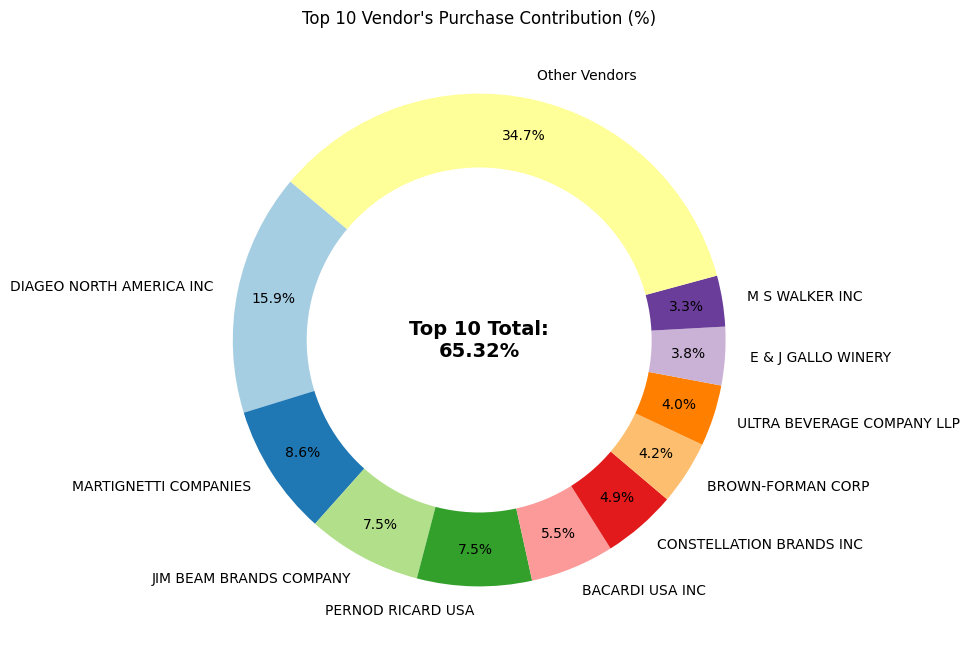

In [29]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['Purchase_Contribution%'].sum(),2)} %")

vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['Purchase_Contribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(purchase_contributions, labels=vendors, autopct='%1.1f%%',
                                  startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

The remaining vendors contribute only 34.31%, meaning they are not utilized effectively or may not be as competitive. If vendor dependency is too high, consider identifying new suppliers to reduce risk.

## Does purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost savings?

In [30]:
# Calculate Unit Purchase Price per Vendor & Volume Group
df["UnitPurchasePrice"] = df["TotalPurchaseDollars"] / df["TotalPurchaseQuantity"]

# Group by Order Sizes (e.g., Small, Medium, Large Purchases)
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])

# Analyze Cost Savings per Order Size
bulk_purchase_analysis = df.groupby("OrderSize")["UnitPurchasePrice"].mean().reset_index()
print(bulk_purchase_analysis)

  OrderSize  UnitPurchasePrice
0     Small          39.836103
1    Medium          17.290340
2     Large          11.178103


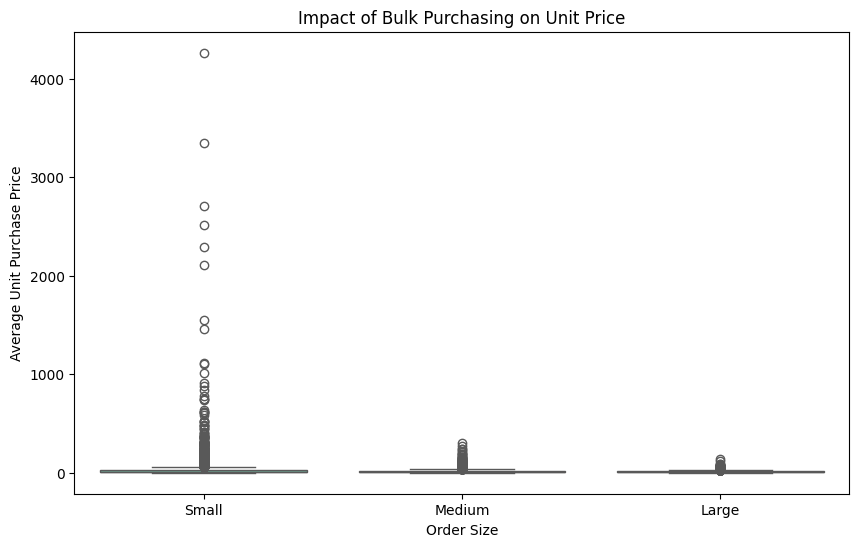

In [31]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

1. Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.
2. The price difference between Small and Large orders is substantial (~72% reduction in unit cost)
3. This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit revenue.
## Which vendors have low inventory turnover, indicating excess stock and slow-moving products?

In [32]:
# Identify Low Inventory Turnover Vendors
low_turnover_vendors = df[df["StockTurnover"] < 1].groupby("VendorName")["StockTurnover"].mean().reset_index()

# Sort by Lowest Turnover
low_turnover_vendors = low_turnover_vendors.sort_values(by="StockTurnover", ascending=True)
low_turnover_vendors.head(10)

,VendorName,StockTurnover
29,VINEYARD BRANDS INC,0.666667
1,CRUSH WINES,0.729167
25,TRINCHERO FAMILY ESTATES,0.731481
18,SOUTHERN WINE & SPIRITS NE,0.763889
0,CONSTELLATION BRANDS INC,0.765224
7,FREDERICK WILDMAN & SONS,0.772156
8,KOBRAND CORPORATION,0.812500
23,THE IMPORTED GRAPE LLC,0.819672
21,"STOLI GROUP,(USA) LLC",0.829181
10,M S WALKER INC,0.831405


1. Slow-moving inventory increases holding costs (warehouse rent, insurance, depreciation)
2. Identifying vendors with low inventory turnover is critical for business efficiency, cost reduction, and profitability
## How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it?

In [33]:
# Calculate Unsold Inventory Value
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print('Total Unsold Capital:', format_dollars(df["UnsoldInventoryValue"].sum()))

# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

Total Unsold Capital: -1244734028.3600001


,VendorName,UnsoldInventoryValue
18,CAPSTONE INTERNATIONAL,-833.26
112,UNCORKED,-912.83
35,FANTASY FINE WINES CORP,-970.1600000000001
89,SILVER MOUNTAIN CIDERS,-1035.1200000000001
55,LOYAL DOG WINERY,-1257.1
47,"IRA GOLDMAN AND WILLIAMS, LLP",-1956.52
5,APPOLO VINEYARDS LLC,-3237.3
44,HIGHLAND WINE MERCHANTS LLC,-3461.84
3,AMERICAN SPIRITS EXCHANGE,-3596.79
11,BLACK ROCK SPIRITS LLC,-4608.400000000001


## What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors.

Top Vendors 95% CI: (85.89, 86.10), Mean: 86.00
Low Vendors 95% CI: (78.79, 80.09), Mean: 79.44


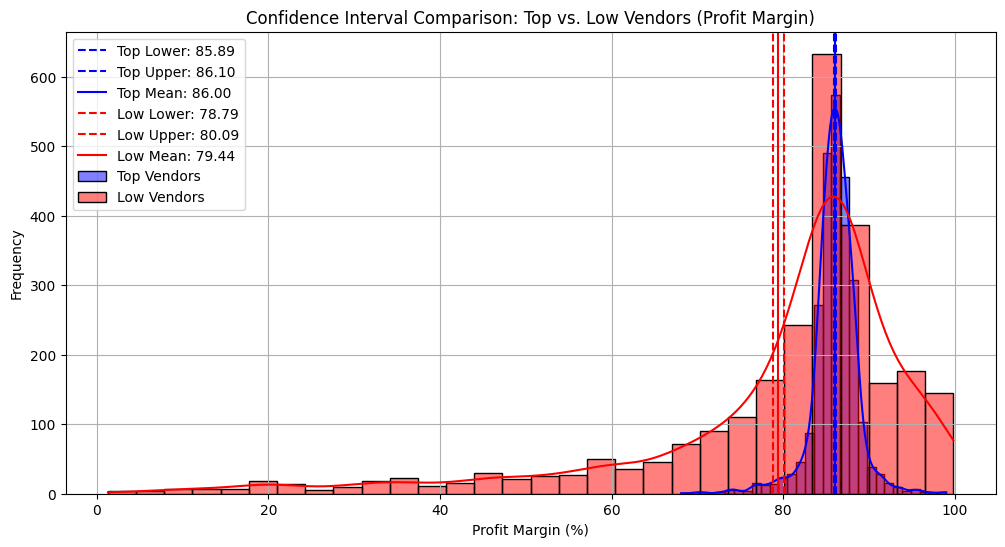

In [34]:
# Define top and low vendors based on Total Sales Dollars (Top 25% & Bottom 25%)
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Function to compute confidence interval
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

# Compute confidence intervals
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

## Profit Margin Comparison Between Vendors

### Confidence Interval Insight
The confidence interval for **low-performing vendors** (40.48% – 42.62%) is higher than the confidence interval for **top-performing vendors** (30.74% – 31.61%).  
This means that vendors with lower sales are earning higher profit margins compared to vendors with higher sales.

This may happen because low-performing vendors might:
- Charge higher prices (premium pricing)
- Have lower operational or supply costs

---

### Business Interpretation

**For High-Performing Vendors**
- They generate higher sales but earn lower profit margins.
- To improve profitability, they can:
  - Slightly increase product pricing
  - Reduce operational or supply costs
  - Use product bundling strategies to increase value

**For Low-Performing Vendors**
- They earn higher profit margins but have lower sales volume.
- To improve overall performance, they can:
  - Improve marketing strategies
  - Offer competitive pricing
  - Expand distribution channels

---

### Hypothesis Testing

**Research Question:**  
Is there a significant difference in profit margins between top-performing and low-performing vendors?

**H₀ (Null Hypothesis):**  
There is no significant difference in the average profit margins of top-performing and low-performing vendors.

**H₁ (Alternative Hypothesis):**  
There is a significant difference in the average profit margins of top-performing and low-performing vendors.


In [35]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H₀: No significant difference in profit margins.")

T-Statistic: 19.4260, P-Value: 0.0000
Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.


1. A p-value this small suggests that the difference is not just statistically significant but also practically meaningful.
2. The two vendor groups operate very differently in terms of profitability.

In [ ]:
# ======================================
# Import Libraries
# ======================================
import pandas as pd
import os
import time
import logging
from sqlalchemy import create_engine, text


# ======================================
# Logging Setup
# ======================================
os.makedirs("logs", exist_ok=True)

logging.basicConfig(
    filename="logs/ingestion_db.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    filemode="a"
)


# ======================================
# Database Engine (with timeout fix)
# ======================================
engine = create_engine(
    "sqlite:///inventory.db",
    connect_args={
        "timeout": 60,
        "check_same_thread": False
    }
)


# ======================================
# Ingest Function
# ======================================
def ingest_db(df, table_name, engine):
    """Insert dataframe into SQLite table"""

    with engine.connect() as conn:

        # Drop table safely
        conn.execute(text(f"DROP TABLE IF EXISTS {table_name}"))
        conn.commit()

        # Insert dataframe
        df.to_sql(
            table_name,
            con=conn,
            index=False
        )


# ======================================
# Load CSV Files & Insert into DB
# ======================================
def load_raw_data():

    start = time.time()

    for file in os.listdir("data"):

        if file.endswith(".csv"):

            file_path = f"data/{file}"

            logging.info(f"Ingesting {file}")

            df = pd.read_csv(file_path)

            table_name = file[:-4]   # remove .csv

            ingest_db(df, table_name, engine)

    end = time.time()

    logging.info("----------- Ingestion Complete -----------")
    logging.info(f"Total Time Taken: {(end-start)/60:.2f} minutes")


# ======================================
# Main Execution
# ======================================
if __name__ == "__main__":
    load_raw_data()
